##### Importing a lot of things

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec  #grid pels subplots
from matplotlib import colors         #colors
from matplotlib.colors import LogNorm   #normalitza a 0-1 en escala logarítmica 
from matplotlib import patches     #figures
from mpl_toolkits.mplot3d import Axes3D   #eixos en 3D
from mpl_toolkits.axes_grid1 import make_axes_locatable  #per canviar la posició dels eixos
from matplotlib.ticker import NullFormatter   #marques(tics) sense etiquetes en els eixos

from astroML.density_estimation import XDGMM
from astroML.plotting.tools import draw_ellipse
from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG
from astroML.utils.decorators import pickle_results
import os
import pickle

import astropy.table     #paquet per manejar taules de dades
from astropy.table import Table, Column, MaskedColumn   #importa taules, columnes i columnes que emmascaren dades invàlides
from astropy.visualization import astropy_mpl_style  #visualització 
from scipy.stats import gaussian_kde  #representation of a kernel-density estimate using Gaussian kernels.
import seaborn as sns  #llibreria per fer gràfics estadístics
import os.path   #per implementar diferents funcions amb pathnames ("dreceres")

from time import time   #mòdul de funcions de time access 
from sklearn import manifold, datasets #manifold: algoritme de dimensionality reduction 
                                       #sklearn (sci-kit learn): llibreria de Python per machine learning
import umap                #Uniform Manifold Approximation and Projection (UMAP) is a dimensionality reduction technique
from sklearn.decomposition import PCA  #Principal component analysis (PCA). Linear dimensionality reduction using Singular Value    
from sklearn.manifold import TSNE #t-SNE [1] is a tool to visualize high-dimensional data
from itertools import product   #producte cartesià

import obtain_data   #per importar dades d'altres fitxers

#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=16, usetex=True)

# 1. Preparing the sample (selection of RedClumps)
### 1.1 The GALAH DR3 RC sample
The GALAH DR3 red-clump sample is a selection of RC stars from the GALAH DR3 catalogue. I have put together the possibly interesting portions of the catalogs and cut a sample of red clump (RC) stars using topcat: (teff > 4500 && teff < 5100 && logg > 2.3 && logg < 2.55 && is_redclump_bstep > 0.5). This sample contains 37,417 stars.

In [2]:
import importlib   #package per importar coses a python
importlib.reload(obtain_data)

galah_rc = obtain_data.galah_dr3_rc()   

#### 1.2 Prepare the input arrays for XD

In [3]:
galah_rc.get_ndimspace(feh=True, norm="stdev")

X = galah_rc.X            #(10941, 24)
Xerr = galah_rc.Xerr1         #(10941, 24)
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2    #(10941, 24, 24)

Cal calcular una matriu W (mixture matrix)???  no pq errors d'un element no influeixen en errors d'un altre, en una mateixa estrella

###### Funció gaussiana

In [4]:
def gaussian(x, mu, sigma):
    return np.exp(-(x-mu)**2 / (2*sigma**2))

# 2. Computing XDGMM & BIC

### 2.1 compute_XD, BIC & plots

In [13]:
#arrays n_comp vs BIC
n_components_array = np.empty(shape=6)
BIC_array = np.empty(shape=6)

ck = ["k", "r", "gold", "g", "b",
          "orange", "cyan", "lime", "m", "yellow",
          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",
          "grey", "turquoise", "lightpink", "navy", "khaki",
          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",
          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]

#Computing XDGMM
for n_components in range(5,6,5):
    @pickle_results('XD_'+str(n_components)+'clusters.pkl')
    def compute_XD(n_components=n_components, rseed=0, max_iter=100, verbose=True):
        np.random.seed(rseed)
        clf = XDGMM(n_components, max_iter=max_iter, tol=1E-5, verbose=verbose)
        clf.fit(X, Xcov) 
        return clf
    # Fit the model on training set
    clf = compute_XD(n_components)  # la primera vegada que es crida la funció ho guarda a l'arxiu pkl
    
    n_dim = 5   # representarem només 5 dimensions/elements
    np.random.seed(42) 
    
    #Calculate BIC
    logL = clf.logL(X,Xcov)  # logaritme de la likelihood
    k = n_components * ( 1 + n_dim + (n_dim*(n_dim+1)/2) )  # nº de free model parameters
    N = 10941       # nº d'estrelles
    BIC = -(2*logL) + (k*np.log(N))
    index = int((n_components/5)-1)
    
    n_components_array[index] = n_components
    BIC_array[index] = BIC
    
'''#Plotting XDGMM symmetrical plots
    alpha = clf.alpha
    mu = clf.mu
    V = clf.V
    ck = ["k", "r", "gold", "g", "b",
          "orange", "cyan", "lime", "m", "yellow",
          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",
          "grey", "turquoise", "lightpink", "navy", "khaki",
          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",
          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]   #30 colors, un per gaussiana/cluster
    
    
    # Standard distribution
    X = galah_rc.X[:,:]
    labels=galah_rc.abundance_titles[:]

    # Fit and sample from the underlying distribution
    X_sample = clf.sample(X.shape[0])[:,:]   #XD resampling X
    
    
    #------------------------------------------------------------
    # Plot the results (plot de X vs X_sample w elipses)
    print('Plotting XDGMM for '+str(n_dim)+'_dim & '+str(n_components)+'_components')
    f = plt.figure(figsize=(20, 20))
    import matplotlib.gridspec as gridspec

    gs0 = gridspec.GridSpec(n_dim, n_dim)
    gs0.update(left=0.08, bottom=0.08, right=0.92, top=0.92,
               wspace=0.05, hspace=0.05)
    for ii in range(n_dim):
        for jj in range(n_dim):
            ax = plt.Subplot(f, gs0[ii, jj])
            f.add_subplot(ax)
            
            if ii != jj:
                if ii < jj:  #per sobre la diagonal (XD amb elipses)
                    ax.scatter(X_sample[:, ii], X_sample[:, jj], s=4, lw=0, c='k', alpha=.3)
                    for kk in np.argsort(alpha)[::-1]:
                        draw_ellipse([ mu[kk][ii], mu[kk][jj] ],
                                       np.array([[ V[kk][ii,ii], V[kk][ii,jj] ],
                                       [ V[kk][jj,ii], V[kk][jj,jj] ]]),
                                     scales=[2], ax=ax, fc="None", ec=ck[kk],
                                     lw=10*alpha[kk])
                    ax.set_xlim(1.01 * np.min(X[:,ii]), 1.01 * np.max(X[:,ii]))
                    ax.set_ylim(1.01 * np.min(X[:,jj]), 1.01 * np.max(X[:,jj]))

                elif ii > jj:  #per sota la diagonal (standard X)
                    ax.scatter(X[:, jj], X[:, ii],
                               s=4, lw=0, c='k', alpha=.3)
                    ax.set_ylim(1.01 * np.min(X[:,ii]), 1.01 * np.max(X[:,ii]))
                    ax.set_xlim(1.01 * np.min(X[:,jj]), 1.01 * np.max(X[:,jj]))
                    
            else:  #elements de la diagonal
                # Make data histogram!
                ax.set_ylim(0, 0.16)
                ax.set_xlim(1.01 * np.min(X[:,jj]), 1.01 * np.max(X[:,jj]))
                #mask = (np.sqrt(exlist[ii]) < np.max(abs(xlist[ii])) )
                weights = np.ones_like(X[:, ii])/len(X[:, ii])
                ax.hist(X[:, ii], weights=weights, bins=50,
                        histtype='stepfilled', alpha=0.4)
                xx = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
                # Overplot Gaussians
                binwidth = (ax.get_xlim()[1] - ax.get_xlim()[0]) / 50.
                for kk in np.argsort(alpha)[::-1]:
                    mukk = mu[kk][ii]
                    sig= np.sqrt( V[kk][ii,ii] )
                    ax.plot(xx, binwidth * alpha[kk] * gaussian(xx, mukk, sig),
                            c=ck[kk])
                    
            # Beautify axes
            if ii == n_dim - 1:
                ax.set_xlabel(labels[jj], fontsize=13)
            elif ii == 0:
                ax2 = ax.twiny()
                ax2.set_xlim(ax.get_xlim())
                ax2.set_xlabel(labels[jj], fontsize=13)
                ax.xaxis.set_major_formatter(plt.NullFormatter())
            else:
                ax.xaxis.set_major_formatter(plt.NullFormatter())
            if jj == 0:
                ax.set_ylabel(labels[ii], fontsize=13)
            elif jj == n_dim - 1:
                ax2 = ax.twinx()
                ax2.set_ylim(ax.get_ylim())
                ax2.set_ylabel(labels[ii], fontsize=13)
                ax.yaxis.set_major_formatter(plt.NullFormatter())
            else:
                ax.yaxis.set_major_formatter(plt.NullFormatter())
                
    plt.savefig("../im/XD(n_dim,n_components)/XD_" +
                str(n_dim)+"d_" +
                str(n_components) +
                "components.png", dpi=200)
    plt.clf()'''

@pickle_results: using precomputed results from 'XD_5clusters.pkl'


'#Plotting XDGMM symmetrical plots\n    alpha = clf.alpha\n    mu = clf.mu\n    V = clf.V\n    ck = ["k", "r", "gold", "g", "b",\n          "orange", "cyan", "lime", "m", "yellow",\n          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",\n          "grey", "turquoise", "lightpink", "navy", "khaki",\n          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",\n          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]   #30 colors, un per gaussiana/cluster\n    \n    \n    # Standard distribution\n    X = galah_rc.X[:,:]\n    labels=galah_rc.abundance_titles[:]\n\n    # Fit and sample from the underlying distribution\n    X_sample = clf.sample(X.shape[0])[:,:]   #XD resampling X\n    \n    \n    #------------------------------------------------------------\n    # Plot the results (plot de X vs X_sample w elipses)\n    print(\'Plotting XDGMM for \'+str(n_dim)+\'_dim & \'+str(n_components)+\'_components\')\n    f = plt.figure(figsize=(20, 20))

### 2.2 (n_components vs BIC)

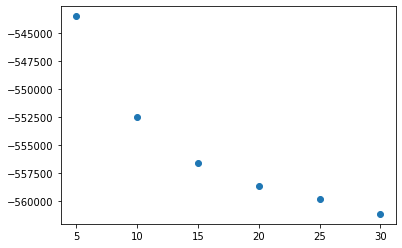

In [8]:
plt.scatter(n_components_array, BIC_array)

### 2.3 XD(n_dim,n_components) symmetrical figures

### 2.4 Cluster Probability Arrays
#### Per ara utilitzem 5 gaussianes

In [6]:
@pickle_results('XD_5clusters.pkl')
def compute_XD(n_components, rseed=0, max_iter=100, verbose=True):
    np.random.seed(rseed)
    clf = XDGMM(n_components, max_iter=max_iter, tol=1E-5, verbose=verbose)
    clf.fit(X, Xcov) 
    return clf
# Fit the model on training set
clf = compute_XD(5)

@pickle_results: using precomputed results from 'XD_5clusters.pkl'


In [7]:
# Probabilities for each star to belong to each group
logprob = (clf.logprob_a(X, Xcov))
prob_per_star = np.exp(logprob) / np.sum(np.exp(logprob), axis=1)[:, np.newaxis]  #(10941 estrelles, 5 probs)

In [8]:
prob_per_star  # p.ex: La primera estrella té un 0,9991 de prob de pertànyer a la 4a gaussiana (4t grup)

array([[3.97816284e-04, 4.00956281e-05, 4.47749724e-04, 9.99109730e-01,
        4.60830776e-06],
       [1.28032978e-06, 3.51289326e-07, 1.43748671e-06, 1.16870714e-03,
        9.98828224e-01],
       [4.38351708e-03, 3.83221093e-05, 3.06433954e-01, 7.37520532e-03,
        6.81769002e-01],
       ...,
       [9.91200029e-01, 2.28144938e-06, 1.54350554e-03, 3.00141379e-08,
        7.25415431e-03],
       [3.39766818e-01, 3.31590016e-06, 7.85106580e-02, 9.96536315e-14,
        5.81719208e-01],
       [3.27793909e-02, 1.81203241e-04, 8.80796544e-04, 9.62188172e-01,
        3.97043744e-03]])

In [9]:
clf.alpha # pesos de les gaussianes: és la suma de totes les probabilitats de cada gaussiana dividit entre la prob total

array([0.12588129, 0.03773479, 0.35944014, 0.21084083, 0.26610295])

In [10]:
np.sum(prob_per_star, axis=0) / np.sum(prob_per_star)   #axis = 0 suma en vertical

array([0.12591913, 0.03775282, 0.3594316 , 0.21088084, 0.26601561])

Observem que dóna el mateix :)

In [11]:
#Cluster with max probability for each star
maxprob_per_star = np.argmax(prob_per_star, axis=1)
maxprob_per_star #index (0,1,2,3,4) del grup més probable a pertànyer de cada estrella

array([3, 4, 4, ..., 0, 4, 3])

# 3. Plotting extra dimensions according to probabilities

### Columns to plot

In [15]:
galah_rc.data.columns.names  #columnes de dades per cada estrella

['star_id',
 'sobject_id',
 'dr2_source_id',
 'dr3_source_id',
 'survey_name',
 'field_id',
 'flag_repeat',
 'wg4_field',
 'wg4_pipeline',
 'flag_sp',
 'teff',
 'e_teff',
 'irfm_teff',
 'irfm_ebv',
 'irfm_ebv_ref',
 'logg',
 'e_logg',
 'fe_h',
 'e_fe_h',
 'flag_fe_h',
 'fe_h_atmo',
 'vmic',
 'vbroad',
 'e_vbroad',
 'chi2_sp',
 'alpha_fe',
 'e_alpha_fe',
 'nr_alpha_fe',
 'flag_alpha_fe',
 'flux_A_Fe',
 'chi_A_Fe',
 'Li_fe',
 'e_Li_fe',
 'nr_Li_fe',
 'flag_Li_fe',
 'C_fe',
 'e_C_fe',
 'nr_C_fe',
 'flag_C_fe',
 'O_fe',
 'e_O_fe',
 'nr_O_fe',
 'flag_O_fe',
 'Na_fe',
 'e_Na_fe',
 'nr_Na_fe',
 'flag_Na_fe',
 'Mg_fe',
 'e_Mg_fe',
 'nr_Mg_fe',
 'flag_Mg_fe',
 'Al_fe',
 'e_Al_fe',
 'nr_Al_fe',
 'flag_Al_fe',
 'Si_fe',
 'e_Si_fe',
 'nr_Si_fe',
 'flag_Si_fe',
 'K_fe',
 'e_K_fe',
 'nr_K_fe',
 'flag_K_fe',
 'Ca_fe',
 'e_Ca_fe',
 'nr_Ca_fe',
 'flag_Ca_fe',
 'Sc_fe',
 'e_Sc_fe',
 'nr_Sc_fe',
 'flag_Sc_fe',
 'Sc2_fe',
 'e_Sc2_fe',
 'nr_Sc2_fe',
 'flag_Sc2_fe',
 'Ti_fe',
 'e_Ti_fe',
 'nr_Ti_fe',
 'flag

### 3.1 (R,z)
##### Choosing colour order

<ipython-input-16-f17ee9f27a55>:23: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax1 = fig.add_subplot(1,5,1)
<ipython-input-16-f17ee9f27a55>:32: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax2 = fig.add_subplot(1,5,2)
<ipython-input-16-f17ee9f27a55>:37: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will alwa

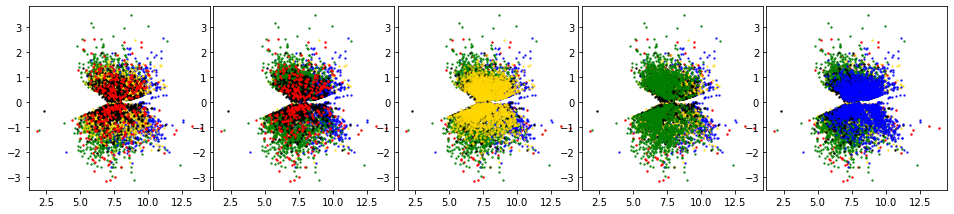

In [16]:
'''Per triar millor plot:
fig = plt.figure(figsize=(15, 50))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)
from sympy.utilities.iterables import multiset_permutations
index_list = np.array([1, 0, 4, 3, 2])
i=0
for p in multiset_permutations(index_list):  #p: una permutació
    i += 1
    print(i,p)
    ax1 = fig.add_subplot(24,5,i)
    for ii in p:         #cada index
        ax1.scatter(galah_rc.data["R_Rzphi"][maxprob_per_star==ii], galah_rc.data["z_Rzphi"][maxprob_per_star==ii], 
                color=ck[ii], s=2, alpha=1-clf.alpha[ii])'''
    
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)
#ordre bo?: verd, blau, groc, negre, vermell
for ii in [3,4,2,0,1]:        # o [1,4,3,2,0]
    ax1 = fig.add_subplot(1,5,1)
    ax1.scatter(galah_rc.data["R_Rzphi"][maxprob_per_star==ii], galah_rc.data["z_Rzphi"][maxprob_per_star==ii], 
                color=ck[ii], s=2, alpha=1-clf.alpha[ii])
    '''         #   s: size,
                #   alpha: transparència,
                #   clf.alpha: pes,
                #   com més pes, menys transparència 
                #   cada color és un cluster en principi '''
for ii in [2,4,3,0,1]:
    ax2 = fig.add_subplot(1,5,2)
    ax2.scatter(galah_rc.data["R_Rzphi"][maxprob_per_star==ii], galah_rc.data["z_Rzphi"][maxprob_per_star==ii], 
                color=ck[ii], s=2, alpha=1-clf.alpha[ii])
    
for ii in [1,4,3,0,2]:
    ax3 = fig.add_subplot(1,5,3)
    ax3.scatter(galah_rc.data["R_Rzphi"][maxprob_per_star==ii], galah_rc.data["z_Rzphi"][maxprob_per_star==ii], 
                color=ck[ii], s=2, alpha=1-clf.alpha[ii])

for ii in [1,4,2,0,3]:
    ax4 = fig.add_subplot(1,5,4)
    ax4.scatter(galah_rc.data["R_Rzphi"][maxprob_per_star==ii], galah_rc.data["z_Rzphi"][maxprob_per_star==ii], 
                color=ck[ii], s=2, alpha=1-clf.alpha[ii])
    
for ii in [1,2,3,0,4]:
    ax5 = fig.add_subplot(1,5,5)
    ax5.scatter(galah_rc.data["R_Rzphi"][maxprob_per_star==ii], galah_rc.data["z_Rzphi"][maxprob_per_star==ii], 
                color=ck[ii], s=2, alpha=1-clf.alpha[ii])
    
#Representacions de (R,z):

El millor és el primer

## R(z)

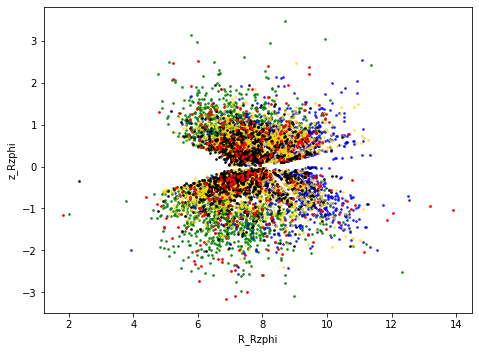

In [17]:
fig = plt.figure(figsize=(7,5))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)
plt.xlabel("R_Rzphi")
plt.ylabel("z_Rzphi")

for ii in [3,4,2,0,1]:      
    plt.scatter(galah_rc.data["R_Rzphi"][maxprob_per_star==ii], galah_rc.data["z_Rzphi"][maxprob_per_star==ii], 
                color=ck[ii], s=3, alpha=1-clf.alpha[ii])

Estrelles blaves més allunyades del centre de la galàxia i més en el seu pla que les verdes, que estan més aprop i arriben més amunt del pla galàctic.

## L_z (Energy): Lindblad diagram

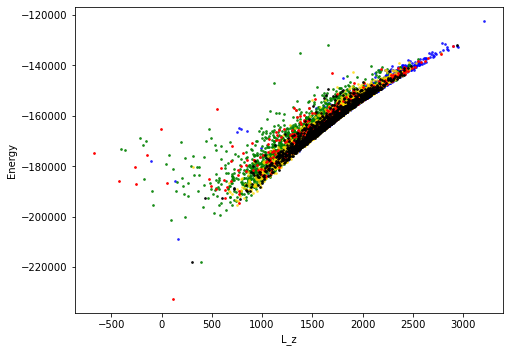

In [27]:
fig = plt.figure(figsize=(7,5))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)
plt.xlabel("L_z")
plt.ylabel("Energy")

for ii in [4,3,2,1,0]:      
    plt.scatter(galah_rc.data['L_Z'][maxprob_per_star==ii], galah_rc.data['Energy'][maxprob_per_star==ii], 
                color=ck[ii], s=3, alpha=1-clf.alpha[ii])

## L_z (Energy): TOOMRE diagram

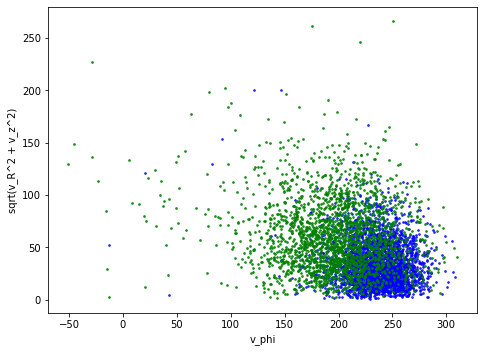

In [33]:
fig = plt.figure(figsize=(7,5))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)
plt.xlabel("v_phi")
plt.ylabel("sqrt(v_R^2 + v_z^2)")

for ii in [4,3]:      
    plt.scatter(galah_rc.data['vT_Rzphi'][maxprob_per_star==ii],
                np.sqrt(((galah_rc.data['vR_Rzphi'][maxprob_per_star==ii])**2) + ((galah_rc.data['vz_Rzphi'][maxprob_per_star==ii])**2)), 
                color=ck[ii], s=3, alpha=1-clf.alpha[ii])

## ecc(z_max)

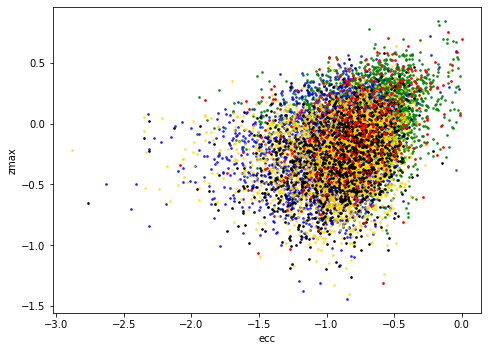

In [18]:
fig = plt.figure(figsize=(7, 5))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

plt.xlabel("ecc")
plt.ylabel("zmax")

for ii in [3,4,2,0,1]:
    plt.scatter(np.log10(galah_rc.data["ecc"][maxprob_per_star==ii]), np.log10(galah_rc.data["zmax"][maxprob_per_star==ii]), 
                color=ck[ii], s=3, alpha=1-clf.alpha[ii])
    #blau: excentricitats més baixes
    #verd: excentricitats més altes

Més excentricitat comporta normalment z_max més alta sobre el pla de la galàxia.

S'observen diferències sobretot en els colors verd (ecc més altes) i blau (ecc baixes)

# 3D plot

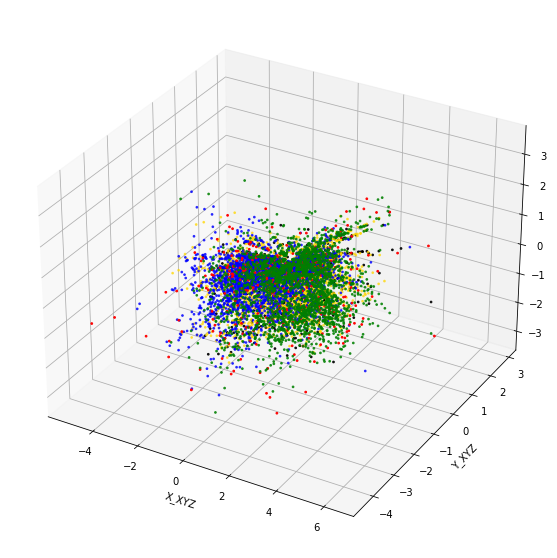

In [19]:
from mpl_toolkits import mplot3d
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
plt.xlabel("X_XYZ")
plt.ylabel("Y_XYZ")
'''ck = ["k", "r", "gold", "g", "b",
          "orange", "cyan", "lime", "m", "yellow",
          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",
          "grey", "turquoise", "lightpink", "navy", "khaki",
          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",
          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]''' #per recordar els colors
for ii in [0,1,2,3,4]:
    ax.scatter3D(galah_rc.data["X_XYZ"][maxprob_per_star==ii],
             galah_rc.data["Y_XYZ"][maxprob_per_star==ii],
             galah_rc.data["Z_XYZ"][maxprob_per_star==ii],
             color=ck[ii], s=3, alpha=1-clf.alpha[ii])
    

# Cinematic plots

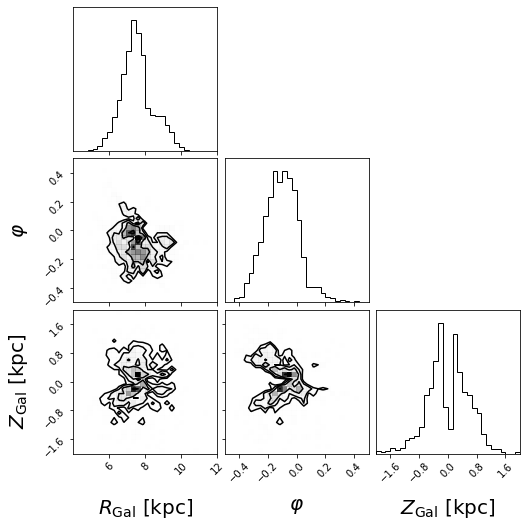

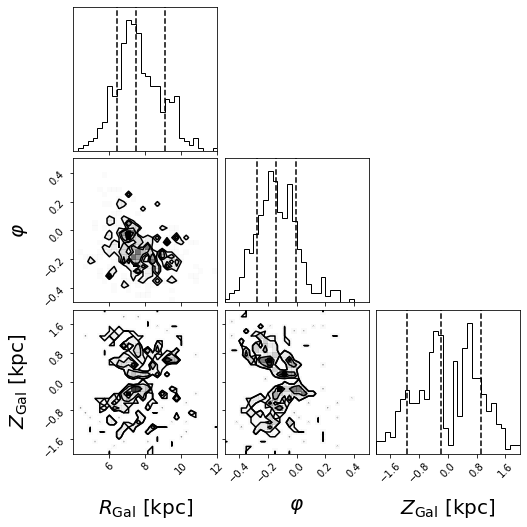

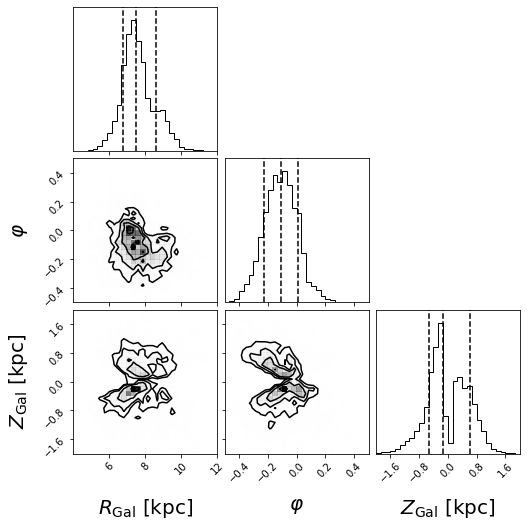

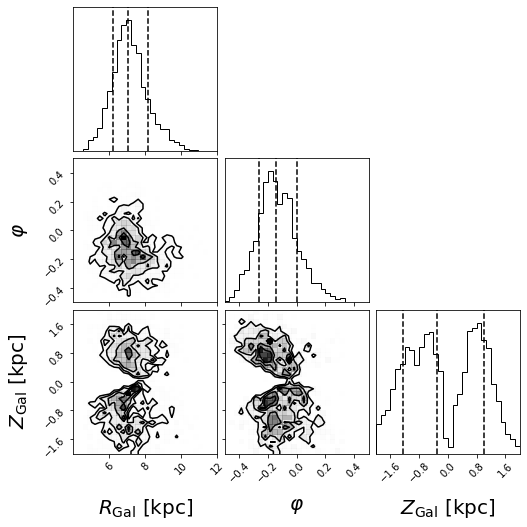

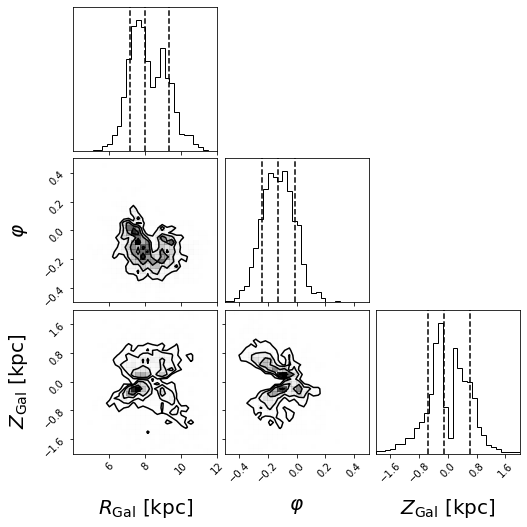

In [132]:
# Fem un plot per cada cluster
# Corner no deixa fer els plots amb diferents colors, cal superposar-los. com?
import corner
for ii in [0,1,2,3,4]:
    R_phi_z = np.array([galah_rc.data["R_Rzphi"][maxprob_per_star==ii],
                                     galah_rc.data["phi_Rzphi"][maxprob_per_star==ii],
                                     galah_rc.data["z_Rzphi"][maxprob_per_star==ii]]).T
    figure = corner.corner(R_phi_z, 
                            weights=None,
                            bins=30, 
                            range=[[4,12],[-.5,0.5],[-2,2]],
                            labels=[r"$R_{\rm Gal}$ [kpc]", r"$\varphi$", r"$Z_{\rm Gal}$ [kpc]"],
                            quantiles=[0.16, 0.5, 0.84],
                            plot_datapoints=False,
                            show_titles=False,
                            label_kwargs={"fontsize": 20})
    plt.savefig("../im/(R,phi,z)cluster"+str(ii+1)+".png")

In [133]:
# Intentem fer els plots de dalt superposats i cadascun amb un color diferent
"""Demo to overlay multiple corners on top of each other"""
import corner
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np


CORNER_KWARGS = dict( 
                    #quantiles=[0.16, 0.5, 0.84],    #(són línies verticals discontínues de separació)
                    #plot_datapoints=True,
                    #range=[[-2.5,1],[-1.5,1]],   #rang dels eixos, no canvia????
                    show_titles=False,
                    label_kwargs={"fontsize": 20},    
                    smooth=0.9,
                    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
                    plot_density=False,
                    fill_contours=True,
                    max_n_ticks=4)


def overlaid_corner(samples_list, sample_labels, file):
    """Plots multiple corners on top of each other"""
    # get some constants
    n = len(samples_list)  # nombre de clusters
    _, ndim = samples_list[0].shape  # dimensions a representar (R,phi,z)
    max_len = max([len(s) for s in samples_list])
    ck = ["k", "r", "gold", "g", "b",   # colors dels clusters
          "orange", "cyan", "lime", "m", "yellow",
          "indianred", "hotpink", "peru", "cornflowerblue", "olivedrab",
          "grey", "turquoise", "lightpink", "navy", "khaki",
          "darkgreen", "crimson", "deepskyblue", "sandybrown", "limegreen",
          "deeppink", "dodgerblue", "rebeccapurple", "teal", "magenta"]

    plot_range = []
    for dim in range(ndim):  # cada dimensió
        plot_range.append([min([min(samples_list[i].T[dim]) for i in range(n)]),
                           max([max(samples_list[i].T[dim]) for i in range(n)])])

    CORNER_KWARGS.update(range=plot_range)
    
   
    #  samples_list = [ [dims_cluster1],  [dims_cluster2], [dims_cluster3] ]
    
    fig = corner.corner(samples_list[0],   # primer cluster
                        color=ck[0],
                        **CORNER_KWARGS)

  
    for idx in range(1, n):       # pels altres clusters
        fig = corner.corner(samples_list[idx],
                            fig=fig,
                            weights=get_normalisation_weight(len(samples_list[idx]), max_len),
                            labels=sample_labels,
                            color=ck[idx],
                            **CORNER_KWARGS)
        
    legend_labels = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5",
                     "Cluster 6", "Cluster 7", "Cluster 8", "Cluster 9", "Cluster 10"]
        
    plt.legend(handles=[mlines.Line2D([], [], color=ck[i], label=legend_labels[i]) for i in range(n)],
                        fontsize=10, 
                        frameon=False,
                        bbox_to_anchor=(1, ndim),
                        loc="upper right")
        
    plt.savefig(file)
    plt.close()


'''def get_normalisation_weight(len_current_samples, len_of_longest_samples):
    return np.ones(len_current_samples) * (len_of_longest_samples / len_current_samples)


def main():
    ndim, nsamples = 3, 10000
    samples = np.random.randn(ndim * nsamples).reshape([nsamples, ndim])

    overlaid_corner(
        [samples * 3, samples * 2, samples],
        ["samples x 3", "samples x 2", "samples"],
        file
    )


if __name__ == "__main__":
    main()'''



'def get_normalisation_weight(len_current_samples, len_of_longest_samples):\n    return np.ones(len_current_samples) * (len_of_longest_samples / len_current_samples)\n\n\ndef main():\n    ndim, nsamples = 3, 10000\n    samples = np.random.randn(ndim * nsamples).reshape([nsamples, ndim])\n\n    overlaid_corner(\n        [samples * 3, samples * 2, samples],\n        ["samples x 3", "samples x 2", "samples"],\n        file\n    )\n\n\nif __name__ == "__main__":\n    main()'

In [135]:
# R vs phi vs z:
R_phi_z = []  # construim una llista de matrius: 1a matriu es R,phi,z(columnes) pel primer cluster, 2a ...
for ii in [0,1,2,3,4]:
    R_phi_z.append(np.array([galah_rc.data["R_Rzphi"][maxprob_per_star==ii],
                             galah_rc.data["phi_Rzphi"][maxprob_per_star==ii],
                             galah_rc.data["z_Rzphi"][maxprob_per_star==ii]]).T)
R_phi_z_labels = [r"$R_{\rm Gal}$ [kpc]", r"$\varphi$", r"$Z_{\rm Gal}$ [kpc]"]



# ecc vs zmax:
ecc_zmax = []
for ii in [0,1,2,3,4]:
    ecc_zmax.append(np.array([np.log10(galah_rc.data["ecc"][maxprob_per_star==ii]),
                             np.log10(galah_rc.data["zmax"][maxprob_per_star==ii])]).T)    
ecc_zmax_labels = [r"e",'$z_{max}$']


  
    
# Execute functions & saving
overlaid_corner(R_phi_z, R_phi_z_labels,"../im/(R,phi,z)_5clusters.png")
overlaid_corner(ecc_zmax, ecc_zmax_labels,"../im/(ecc,zmax)_5clusters.png")